# Week 1

## Model Simulation and Behaviour

## Task 1.1.

In [2]:
import models
import numpy as np
import matplotlib.pyplot as plt
import datavis as dv
from scipy.ndimage import gaussian_laplace as gl
from scipy.ndimage import gaussian_filter

## Ramp Model

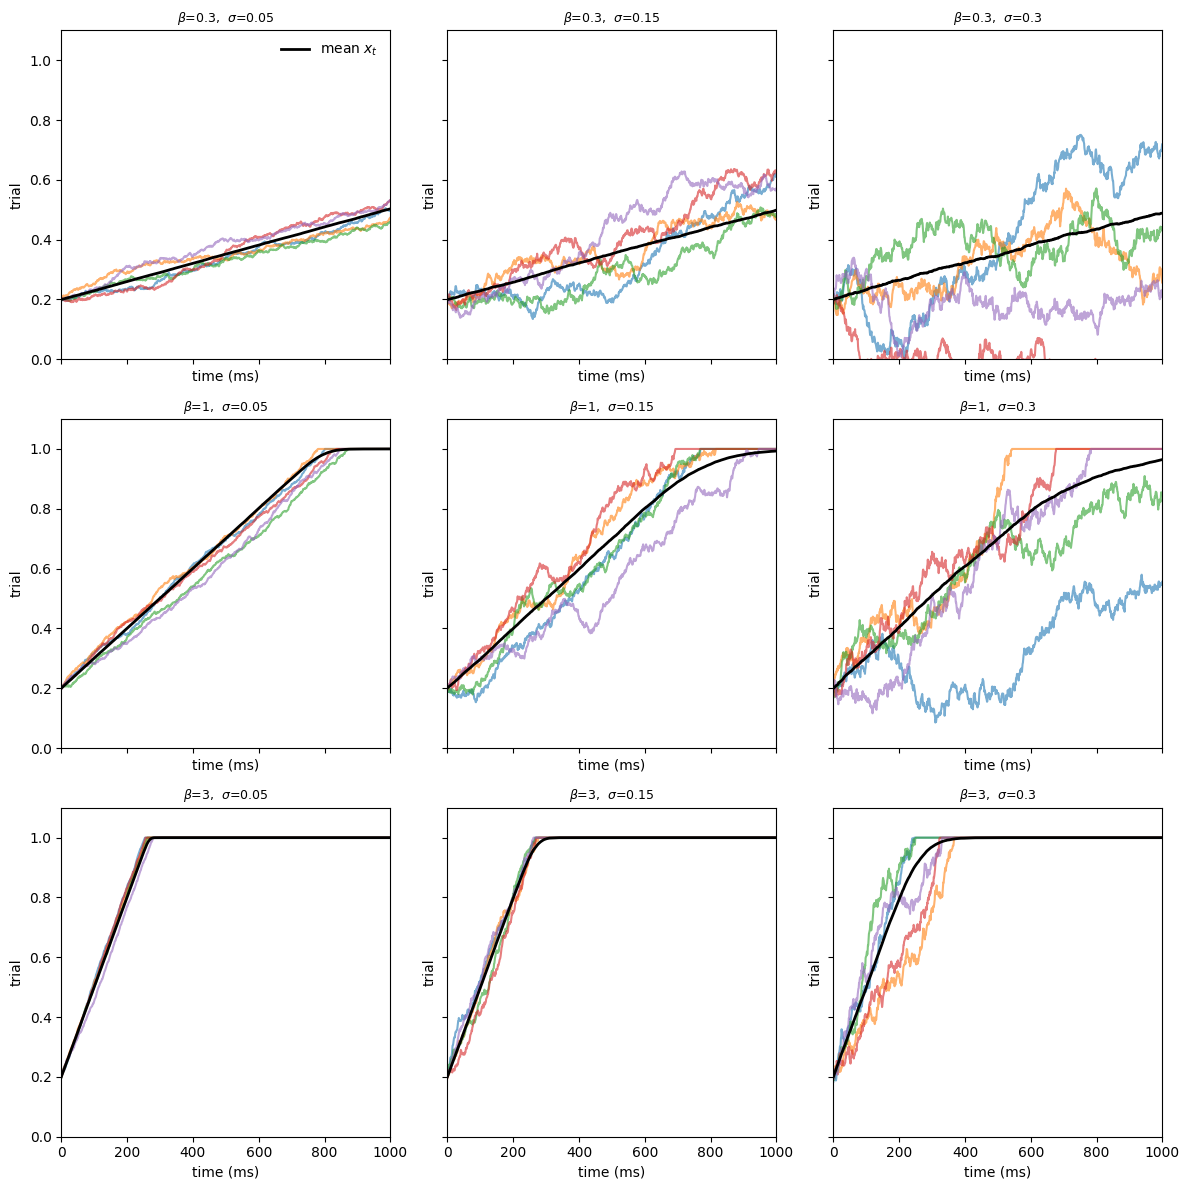

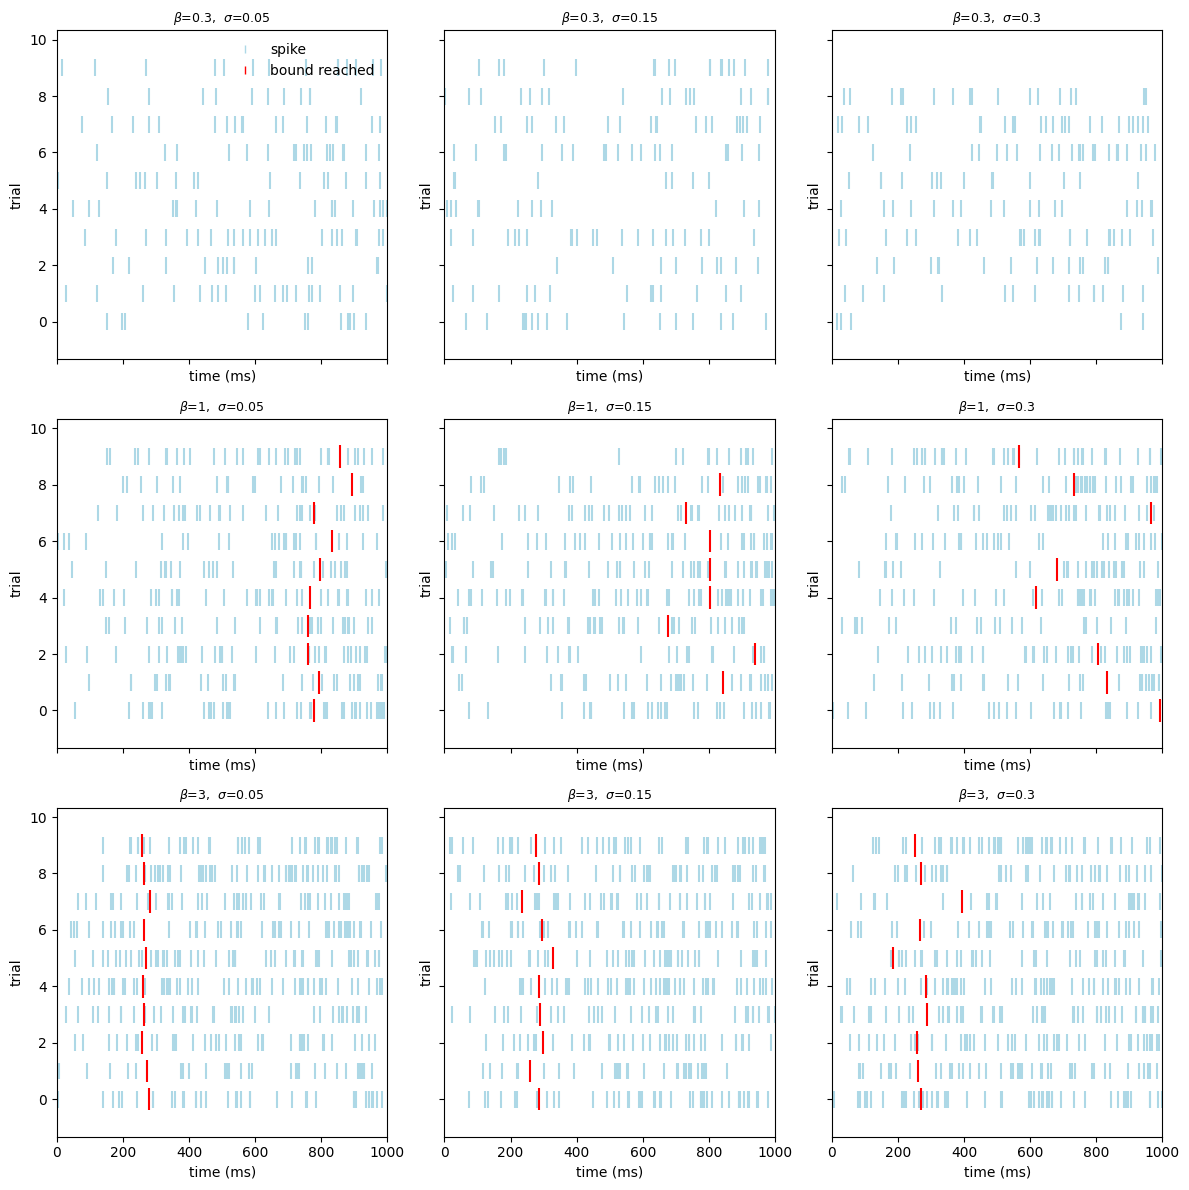

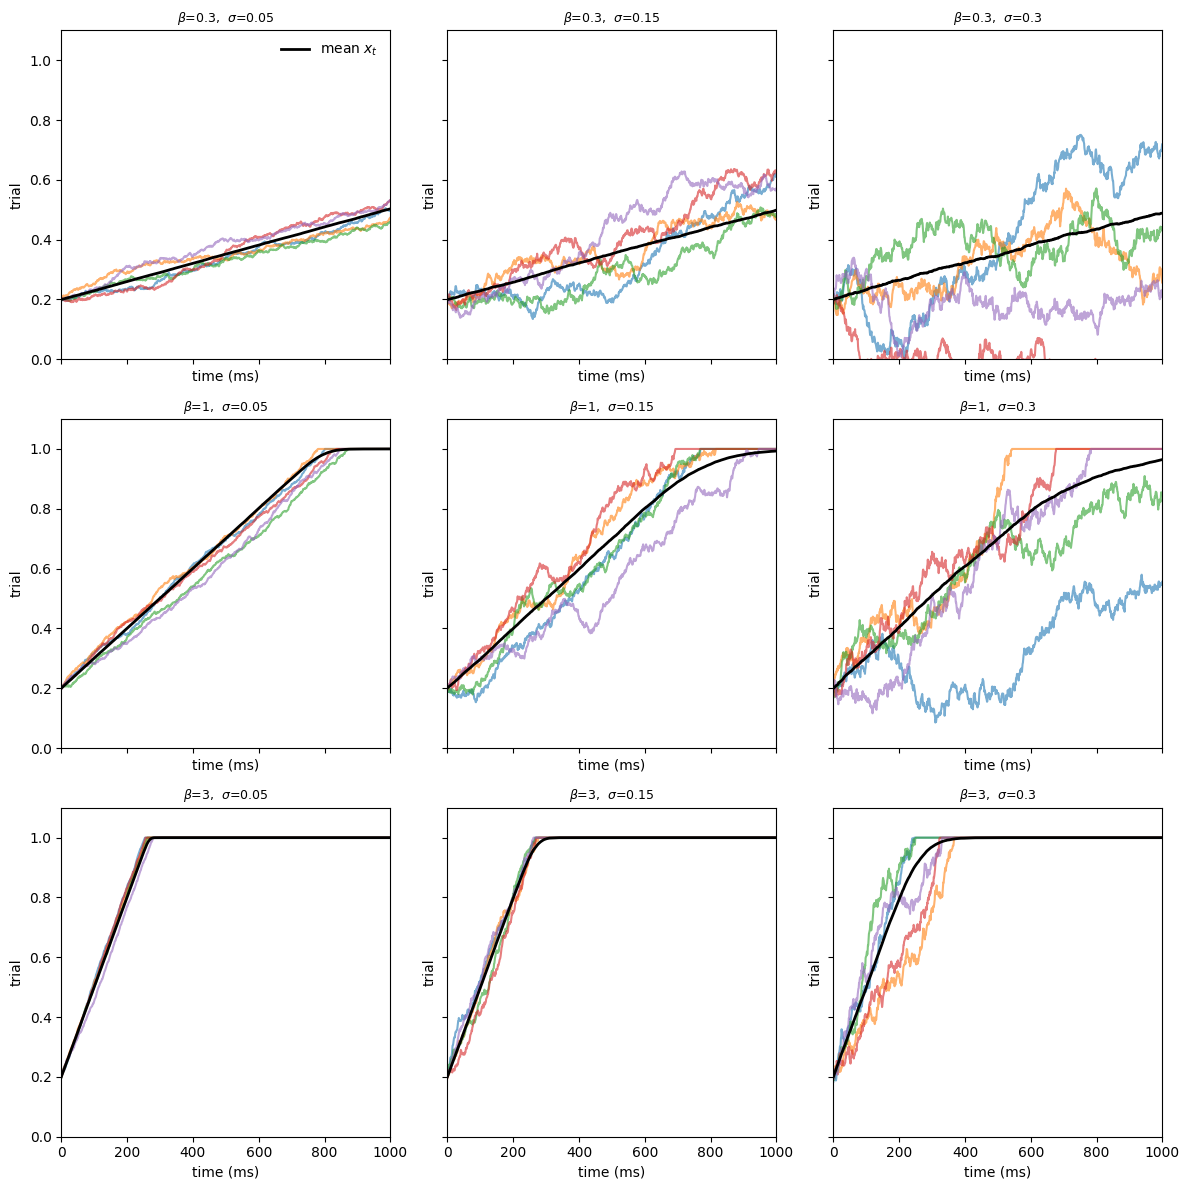

In [3]:
dv.rampRasterPlot()
dv.rampWalkPlot()

## Step Model

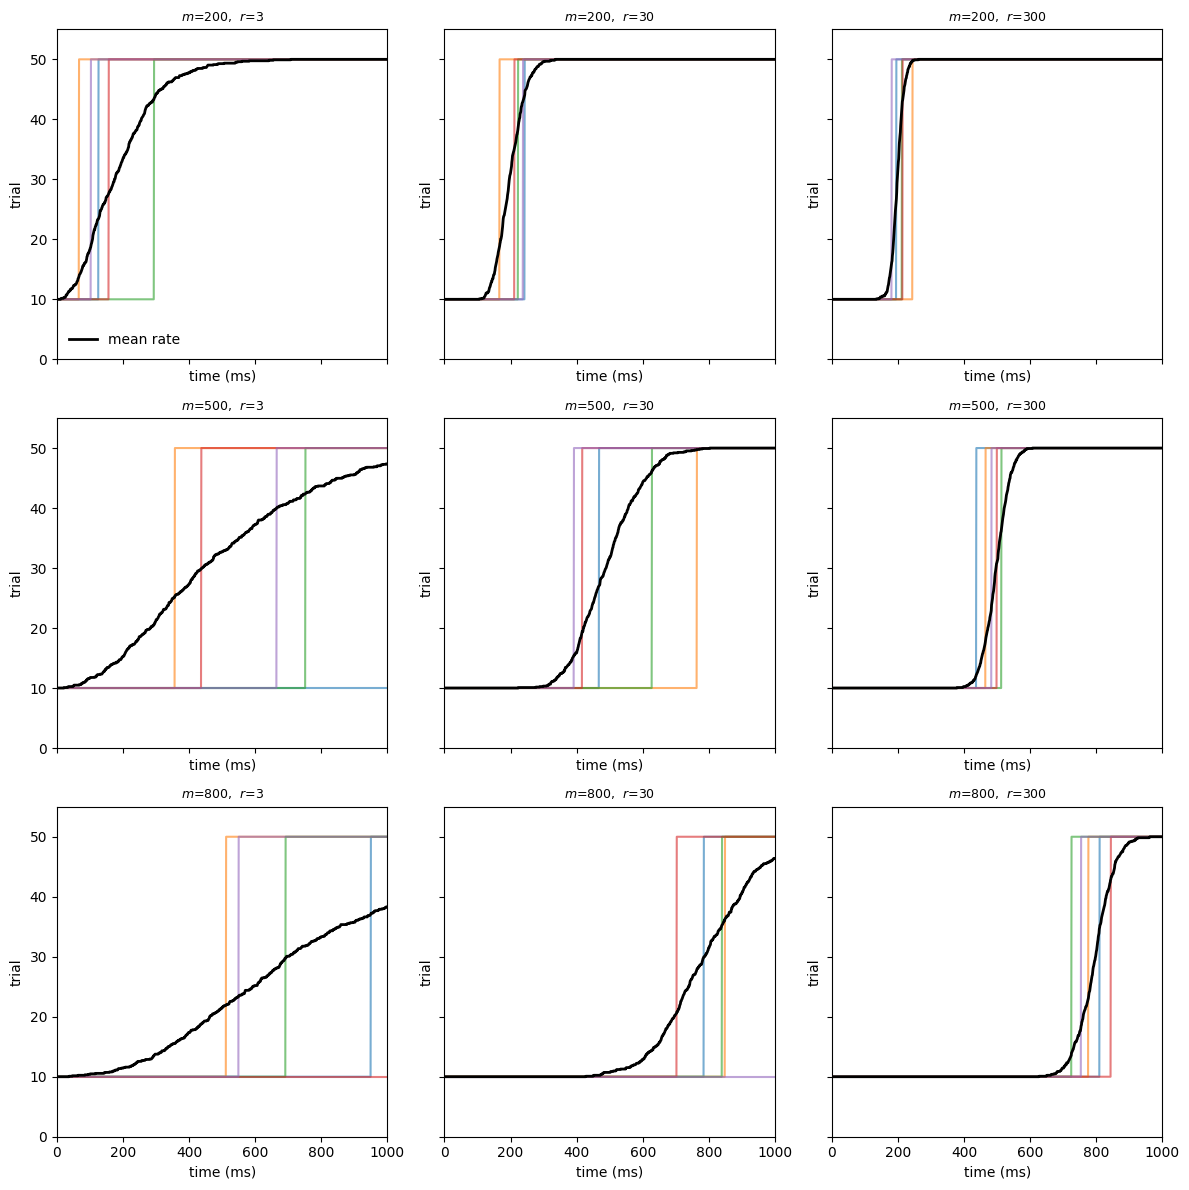

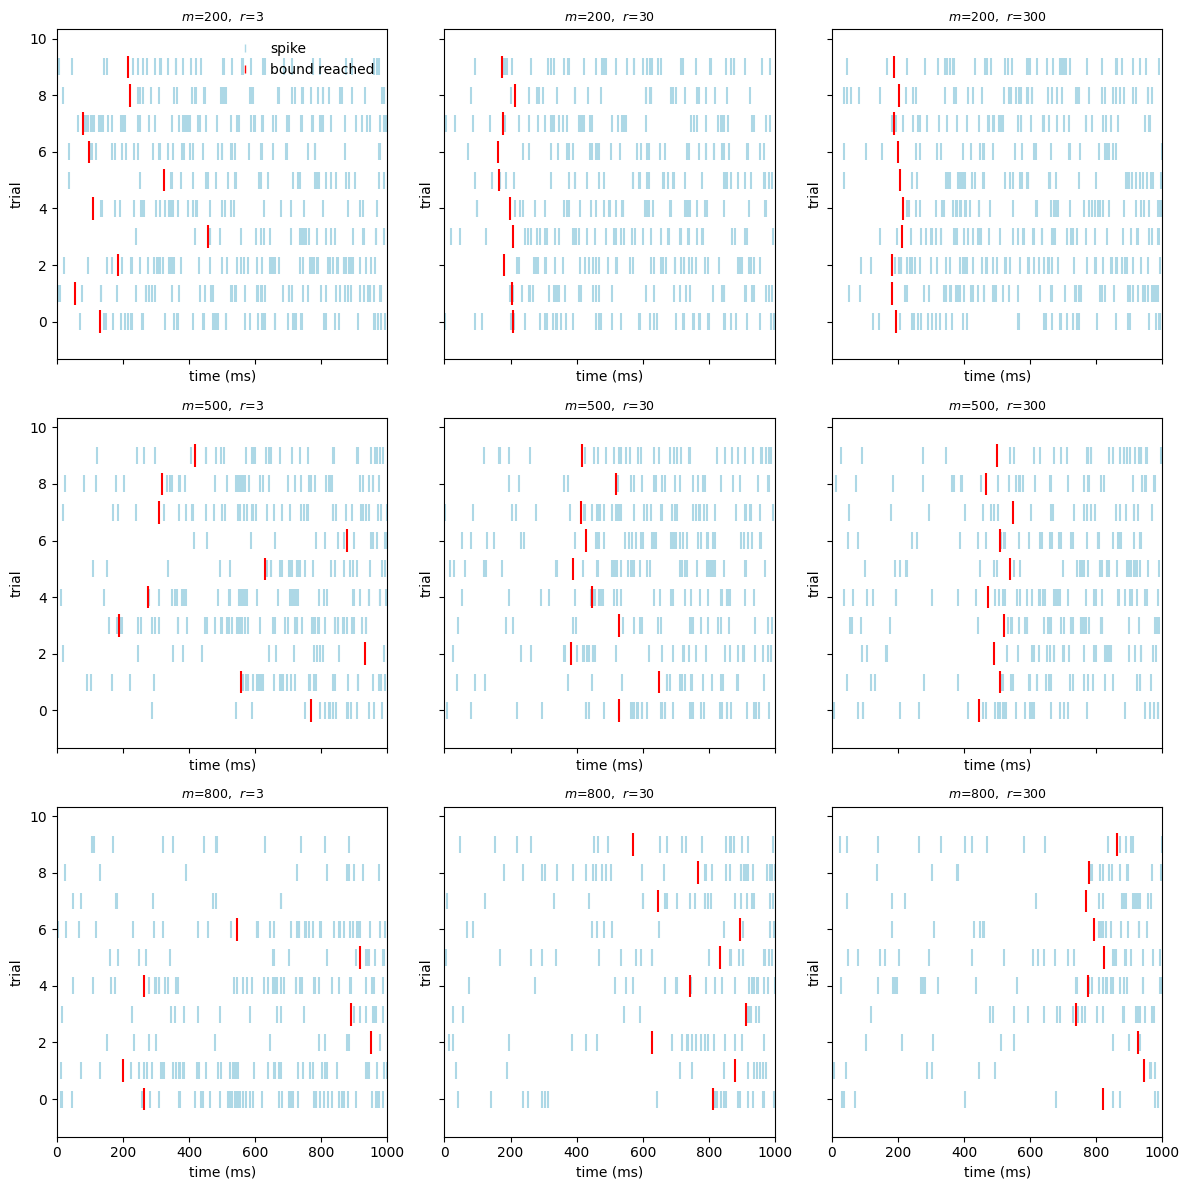

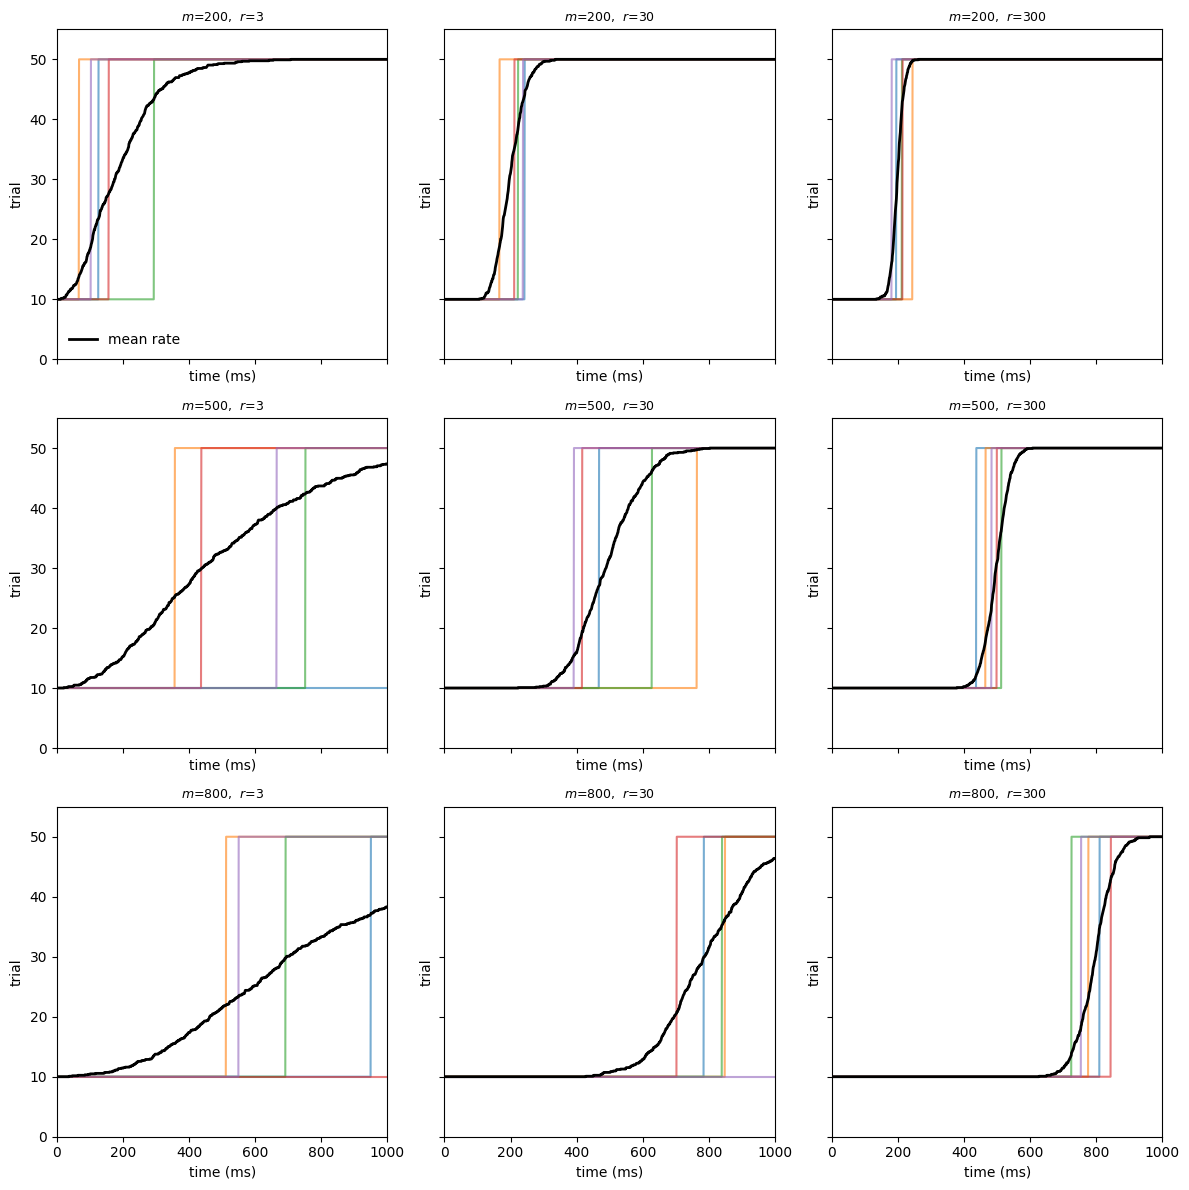

In [4]:
dv.stepRasterPlot()
dv.stepWalkPlot()

## Task 1.2.

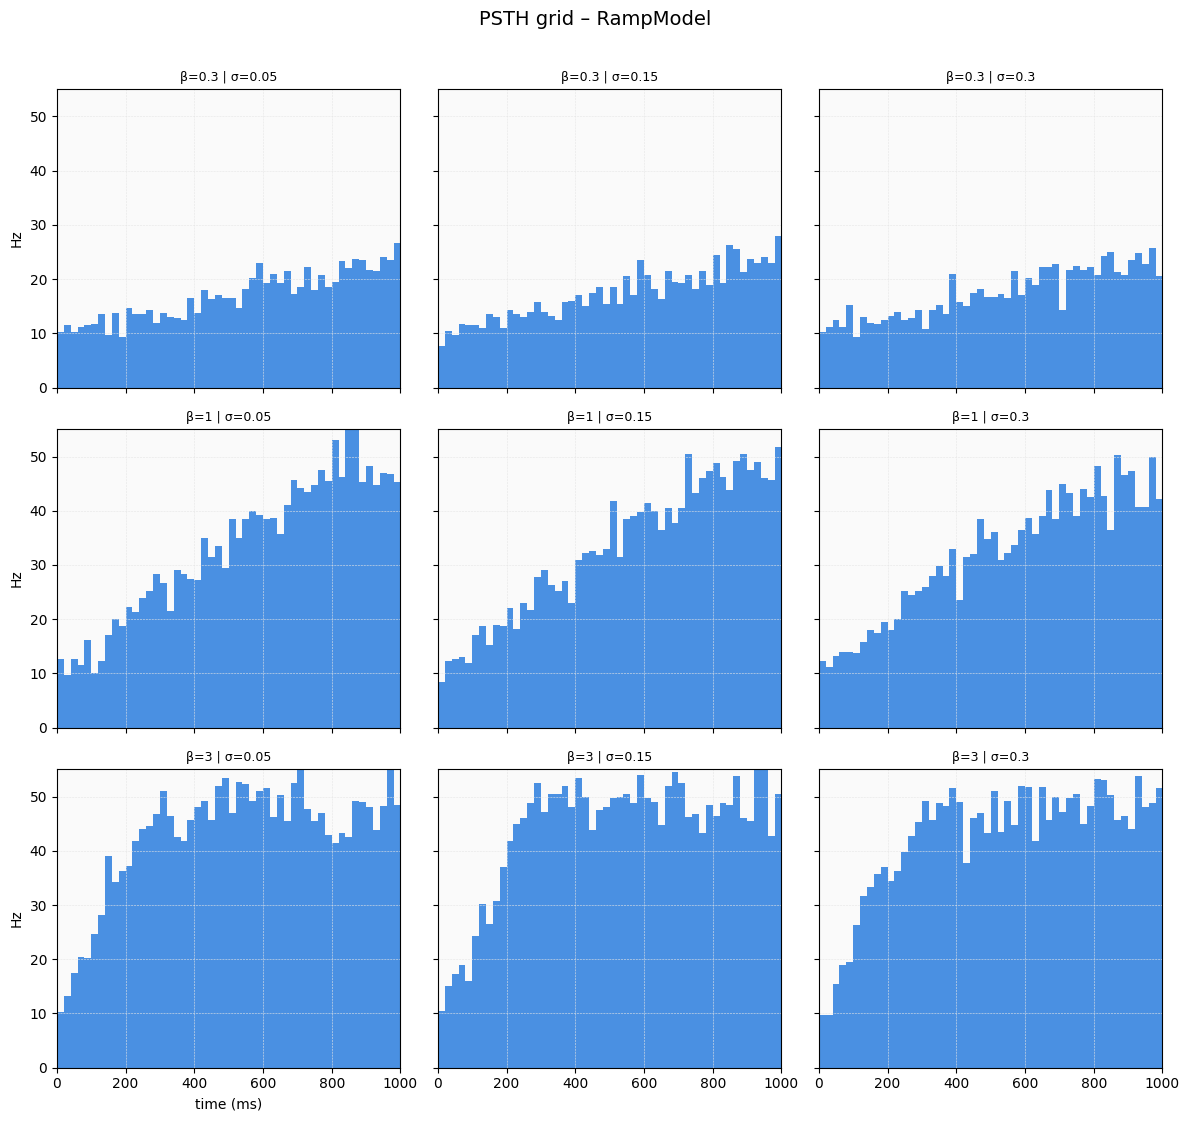

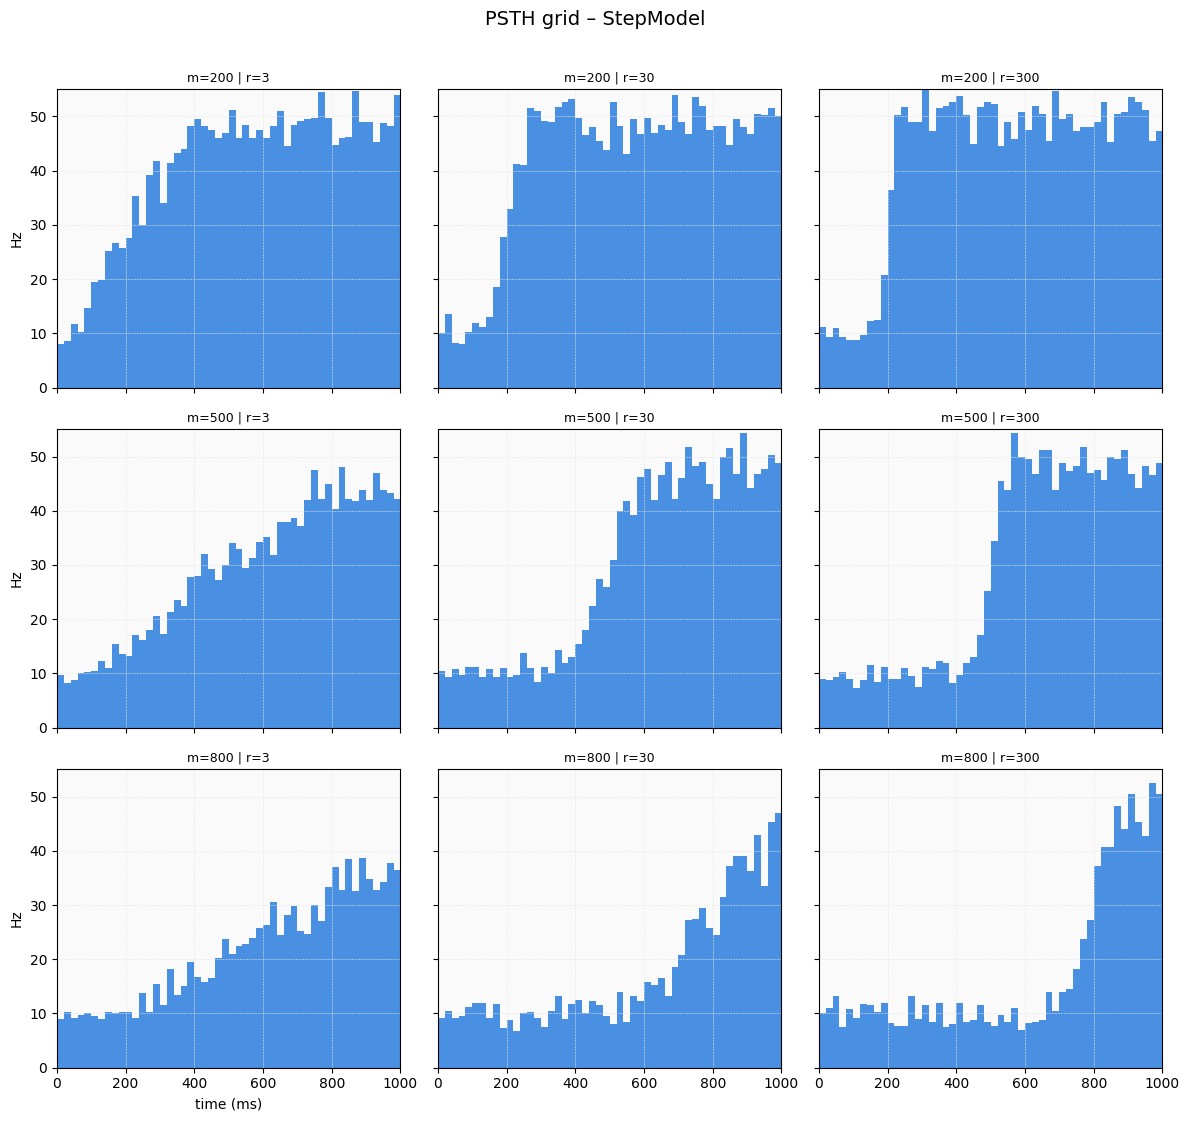

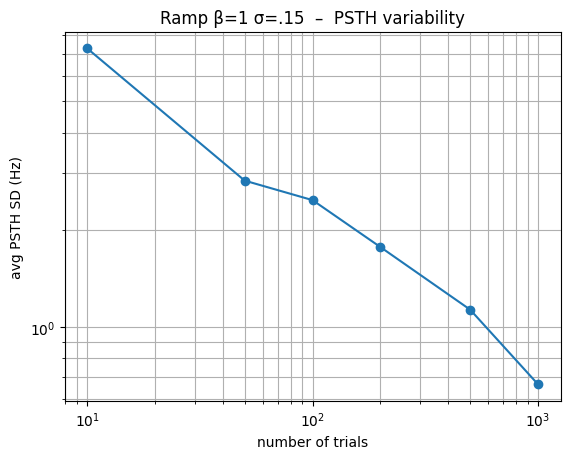

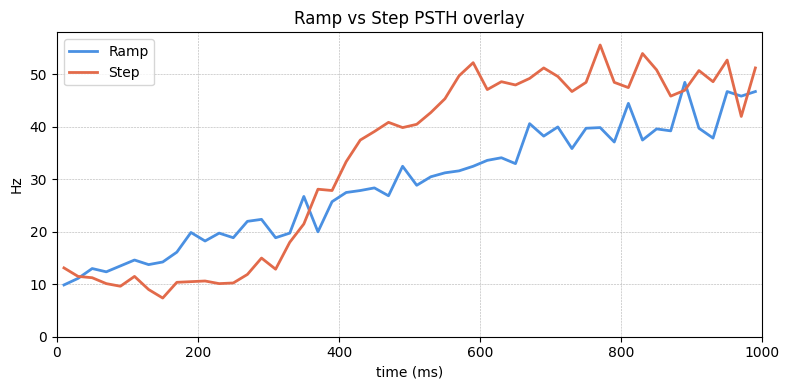

In [5]:
# A) basic PSTH grids
dv.psth_grid(models.RampModel, [0.3,1,3], [0.05,.15,.3], "β", "σ",
          n_trials=200, bin_width=20, smooth_ms=20)
dv.psth_grid(models.StepModel, [200,500,800], [3,30,300], "m", "r",
          n_trials=200, bin_width=20, smooth_ms=20)
plt.show()

# C) trial-count dependence
Ns, errs = dv.psth_variability(models.RampModel, dict(beta=1, sigma=.15))
plt.figure(); plt.loglog(Ns, errs, marker='o');
plt.xlabel("number of trials"); plt.ylabel("avg PSTH SD (Hz)");
plt.title("Ramp β=1 σ=.15  –  PSTH variability"); plt.grid(True, which='both'); plt.show()

# D) Overlay to hunt for matching PSTHs
dv.overlay_psth_comparison(dict(beta=0.8, sigma=.2),
                        dict(m=400, r=20),
                        n_trials=400, bin_width=20, smooth_ms=20)
plt.show()


## Task 1.3.

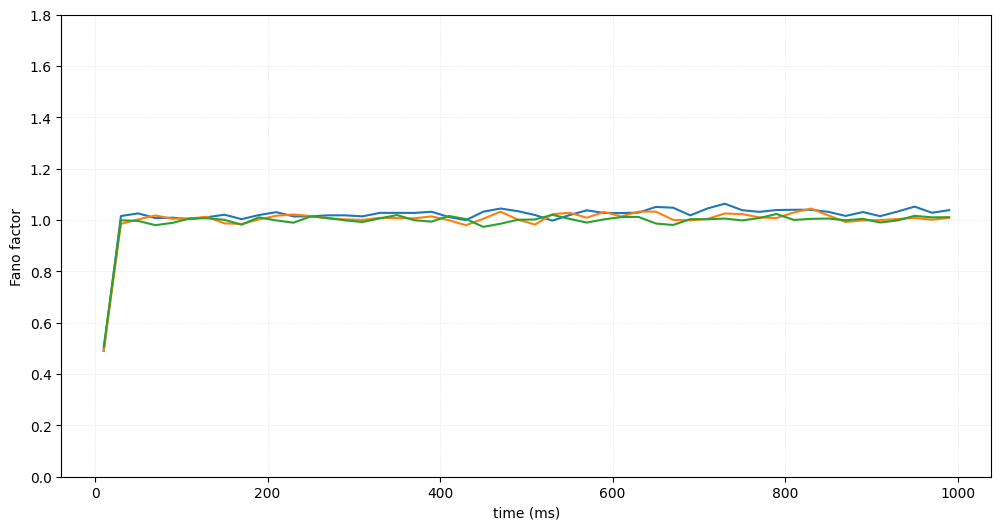

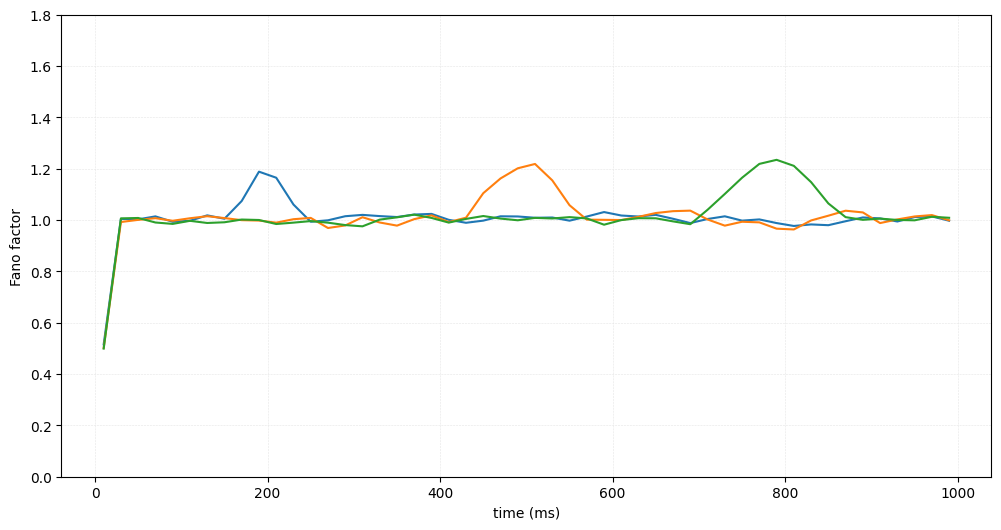

In [6]:
# generate an array of fano factors time series arrays

bw = 20 # bin width for the mean and variances to be calculated along
fanos = np.zeros((6, int(1000/bw)))
# decide some parameters for the models 
fps = [(0.5,0.15),(1,0.15),(3,0.15),(200,10),(500,10),(800,10)]

fig, ax1 = plt.subplots(figsize=(12,6))
fig, ax2 = plt.subplots(figsize=(12,6))

for i in range(3):
    _, fanos[i, :] = dv.fanoFactor(models.RampModel(beta=fps[i][0], sigma=fps[i][1]),
                                bin_width=bw,
                                smooth_ms=40,
                                ax=ax1,
                                plot=True
                            )

for j in range(3):              
    times, fanos[j+3, :] = dv.fanoFactor(models.StepModel(m=fps[j+3][0], r=fps[j+3][0]),
                                    bin_width=bw,
                                    smooth_ms=40,
                                    ax=ax2,
                                    plot=True
                            )

In [7]:
# clip start and end of arrays
n = len(fanos[0])
clip_fac = 0.1 # fraction of array to remove from start and end
fanos = np.array(fanos[:, int(np.floor(n*clip_fac)) : int(np.ceil(n*(1-clip_fac)))])
times = np.array(times[int(np.floor(n*clip_fac)) : int(np.ceil(n*(1-clip_fac)))])

## Task 1.4.

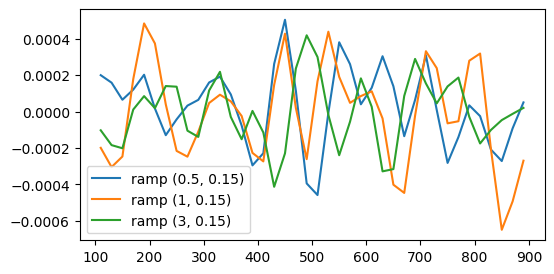

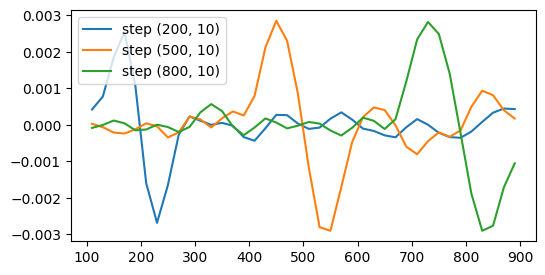

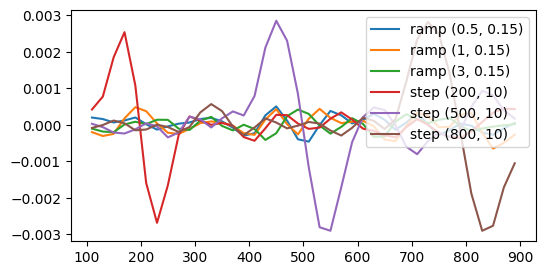

In [8]:
# plot numerical derivatives of fano factor wrt time
fanos_smoothed = np.array([gaussian_filter(fanos[i], sigma=1) for i in range(6)])
gradients = [np.gradient(fanos_smoothed[i], times) for i in range(6)]


fig, ax3 = plt.subplots(figsize=(6,3))
fig, ax4 = plt.subplots(figsize=(6,3))
fig, ax34 = plt.subplots(figsize=(6,3))

for i in range(3):
    ax3.plot(times, gradients[i], label='ramp ' + str(fps[i]))
    ax34.plot(times, gradients[i], label='ramp ' + str(fps[i]))

for j in range(3):
    ax4.plot(times, gradients[j+3], label='step ' + str(fps[j+3]))
    ax34.plot(times, gradients[j+3], label='step ' + str(fps[j+3]))


ax3.legend()
ax4.legend()
ax34.legend()
plt.show()



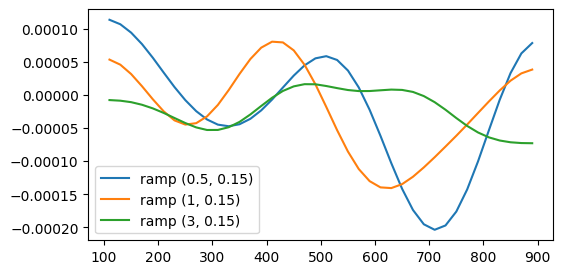

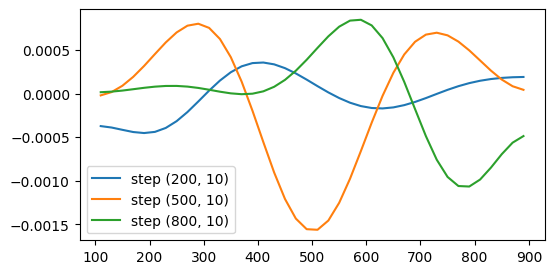

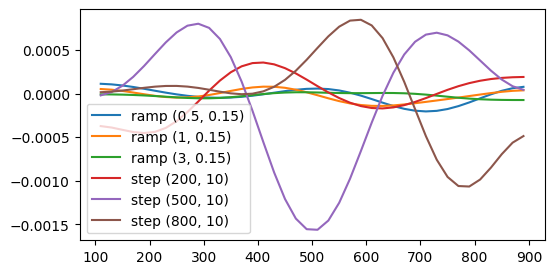

In [9]:
# convolve the fano factor array with Laplacian of Gaussian kernel
LoG_responses = [gl(fanos[i, :], sigma=6) for i in range(6)]


fig, ax5 = plt.subplots(figsize=(6,3))
fig, ax6 = plt.subplots(figsize=(6,3))
fig, ax56 = plt.subplots(figsize=(6,3))

for i in range(3):
    ax5.plot(times, LoG_responses[i], label='ramp '+str(fps[i]))
    ax56.plot(times, LoG_responses[i], label='ramp '+str(fps[i]))

for j in range(3):
    ax6.plot(times, LoG_responses[j+3], label='step '+str(fps[j+3]))
    ax56.plot(times, LoG_responses[j+3], label='step '+str(fps[j+3]))

ax5.legend()
ax6.legend()
ax56.legend()
plt.show()

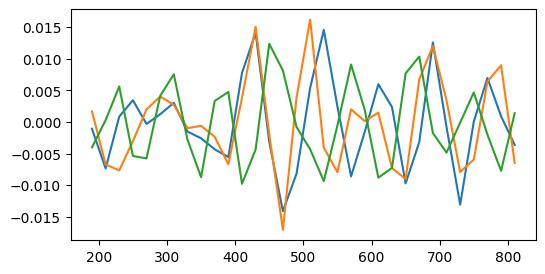

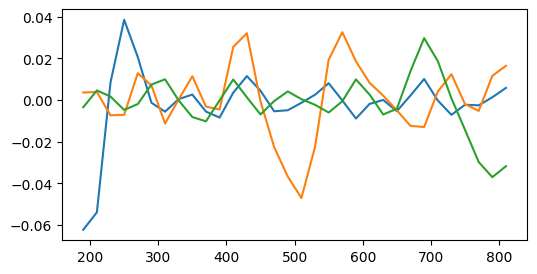

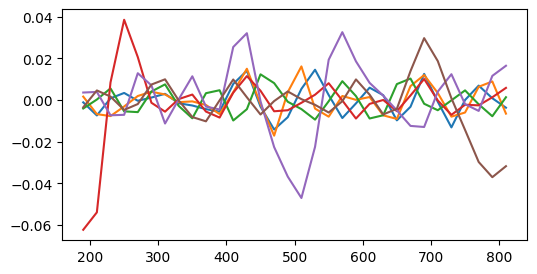

In [10]:
# plot traces of fano factor once convolved with laplacian kernel
laplacians = np.array([dv.laplacian(fanos_smoothed[i], plot=False)  for i in range(6)])

n = len(laplacians[0])
clip_fac = 0.1 # fraction of array to remove from start and end
laplacians = laplacians[:, int(np.floor(n*clip_fac)) : int(np.ceil(n*(1-clip_fac)))]
times = times[int(np.floor(n*clip_fac)) : int(np.ceil(n*(1-clip_fac)))]

fig, ax7 = plt.subplots(figsize=(6,3))
fig, ax8 = plt.subplots(figsize=(6,3))
fig, ax78 = plt.subplots(figsize=(6,3))

for i in range(3):
    ax7.plot(times, laplacians[i])
    ax78.plot(times, laplacians[i])

for j in range(3):
    ax8.plot(times, laplacians[j+3])
    ax78.plot(times, laplacians[j+3])



In [ ]:
from scipy.ndimage import gaussian_filter1d

# generate a dataset
T = 1000
datasize = 20
trials = 400

beta = np.random.uniform(0, 4, datasize)
ln_sig = np.random.uniform(np.log(0.04), np.log(4), datasize)
ramp_params = np.column_stack((beta, np.exp(ln_sig)))

r = np.random.uniform(0.5, 6, datasize)
m = np.random.uniform(T/4, 3*T/4, datasize)
step_params = np.column_stack((m, r))

x_init = np.random.uniform(0, 0.5, datasize*2)

ramp_dataset = np.array([models.RampModel(beta=ramp_params[i,0],
                                      sigma=ramp_params[i,1],
                                      x0 = x_init[i]).simulate(Ntrials=trials,
                                                               T=T)[0]
                                      for i in range(datasize)
                                      ]
                                    )
                                    
step_dataset = np.array([models.StepModel(m=step_params[j,0],
                                      r=step_params[j,1],
                                      x0 = x_init[j+datasize]).simulate(Ntrials=trials,
                                                                   T=T)[0]
                                      for j in range(datasize)
                                      ]
)


dataset = np.vstack((ramp_dataset, step_dataset))

(40, 400, 1000)

In [134]:
# write a classifier
import firstclassifier as fc
bw=20

fanos = np.array([fc.fanofac(dataset[i],
                    bin_width=bw,
                    T=T)[1]
                    for i in range(datasize*2)]
)

n = len(fanos[0])
clip_fac = 0.1 # fraction of array to remove from start and end
fanos = np.array(fanos[:, int(np.floor(n*clip_fac)) : int(np.ceil(n*(1-clip_fac)))])
fanos = gaussian_filter1d(fanos, sigma=1, axis=1)
fanos_clean = np.nan_to_num(fanos, nan=0.0)
f_max = np.max(fanos_clean, axis=1)

classifier = (f_max > 1.22).astype(int)

print(classifier)

[1 0 1 0 0 1 0 0 0 0 1 0 1 0 0 0 0 0 0 0 1 0 1 1 1 1 0 1 1 1 1 0 1 1 1 1 0
 1 1 1]
